In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/sample_data/cardekho_dataset.csv')
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


Problam Statement :-

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [ ]:
df.shape

(15411, 14)

In [ ]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [ ]:
df['car_name'].unique()

array(['Maruti Alto', 'Hyundai Grand', 'Hyundai i20', 'Ford Ecosport',
       'Maruti Wagon R', 'Hyundai i10', 'Hyundai Venue', 'Maruti Swift',
       'Hyundai Verna', 'Renault Duster', 'Mini Cooper', 'Maruti Ciaz',
       'Mercedes-Benz C-Class', 'Toyota Innova', 'Maruti Baleno',
       'Maruti Swift Dzire', 'Volkswagen Vento', 'Hyundai Creta',
       'Honda City', 'Mahindra Bolero', 'Toyota Fortuner', 'Renault KWID',
       'Honda Amaze', 'Hyundai Santro', 'Mahindra XUV500',
       'Mahindra KUV100', 'Maruti Ignis', 'Datsun RediGO',
       'Mahindra Scorpio', 'Mahindra Marazzo', 'Ford Aspire', 'Ford Figo',
       'Maruti Vitara', 'Tata Tiago', 'Volkswagen Polo', 'Kia Seltos',
       'Maruti Celerio', 'Datsun GO', 'BMW 5', 'Honda CR-V',
       'Ford Endeavour', 'Mahindra KUV', 'Honda Jazz', 'BMW 3', 'Audi A4',
       'Tata Tigor', 'Maruti Ertiga', 'Tata Safari', 'Mahindra Thar',
       'Tata Hexa', 'Land Rover Rover', 'Maruti Eeco', 'Audi A6',
       'Mercedes-Benz E-Class', 'Audi Q7'

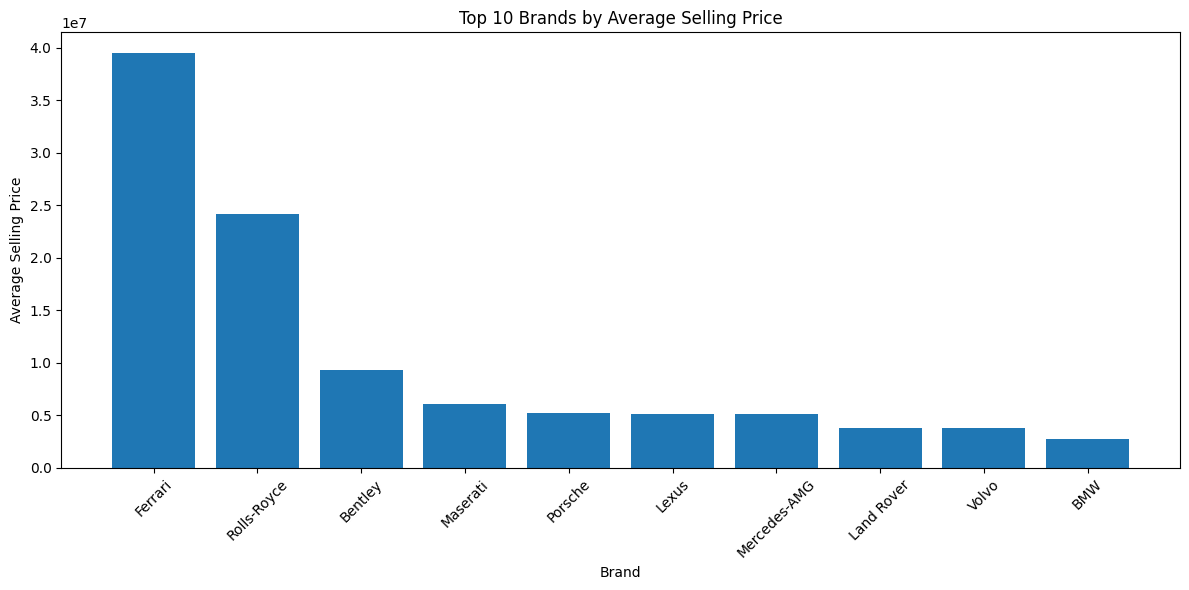

In [ ]:
#Which brands command the highest average selling price, and which brands are the most affordable?
brand_price = (
    df.groupby("brand")["selling_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
plt.bar(brand_price.index.astype(str), brand_price.values)
plt.xticks(rotation=45)
plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Brand")
plt.ylabel("Average Selling Price")
plt.tight_layout()
plt.show()



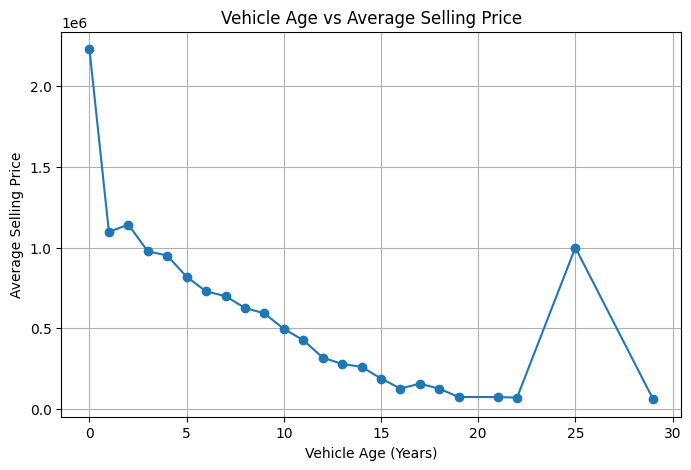

vehicle_age
0     2.230000e+06
1     1.096977e+06
2     1.143023e+06
3     9.770950e+05
4     9.509427e+05
5     8.188928e+05
6     7.285146e+05
7     6.990758e+05
8     6.259454e+05
9     5.924664e+05
10    4.961479e+05
11    4.262377e+05
12    3.182901e+05
13    2.784852e+05
14    2.606822e+05
15    1.883764e+05
16    1.262400e+05
17    1.564706e+05
18    1.250000e+05
19    7.400000e+04
21    7.333333e+04
22    7.000000e+04
25    1.000000e+06
29    6.000000e+04
Name: selling_price, dtype: float64


In [ ]:
#How does the age of a vehicle influence its resale value?
age_price = (
    df.groupby("vehicle_age")["selling_price"]
    .mean()
)

plt.figure(figsize=(8,5))
plt.plot(age_price.index, age_price.values, marker='o')
plt.title("Vehicle Age vs Average Selling Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Average Selling Price")
plt.grid(True)
plt.show()

print(age_price)

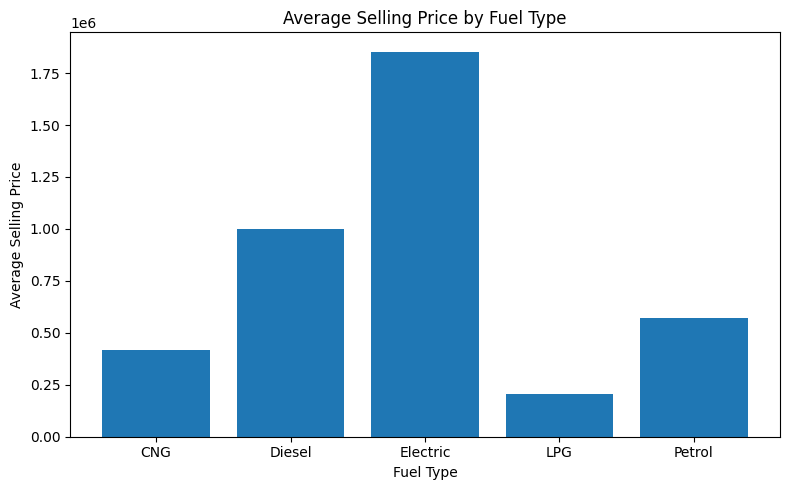

fuel_type
CNG         4.176877e+05
Diesel      1.000469e+06
Electric    1.853500e+06
LPG         2.062727e+05
Petrol      5.728619e+05
Name: selling_price, dtype: float64


In [ ]:
#. Which fuel type has the highest resale value?
fuel_price = (
    df.groupby("fuel_type")["selling_price"]
    .mean()
)

plt.figure(figsize=(8,5))
plt.bar(fuel_price.index, fuel_price.values)
plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.tight_layout()
plt.show()

print(fuel_price)

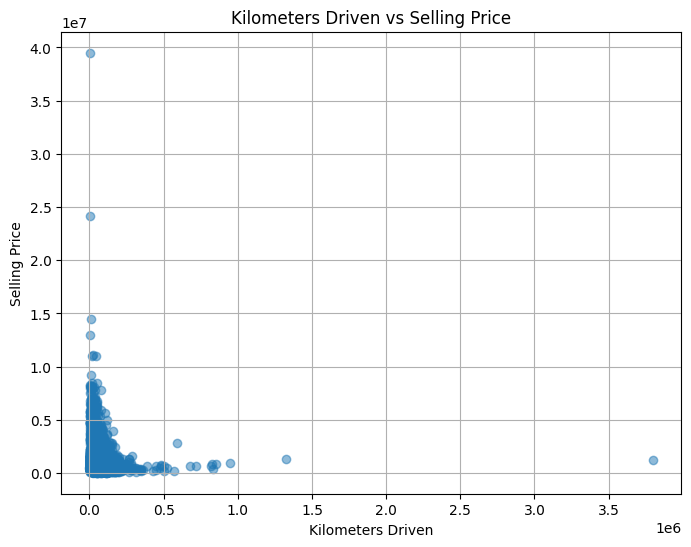

In [ ]:
#5. Relationship between Kilometers Driven and Selling Price
plt.figure(figsize=(8,6))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.5)
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()

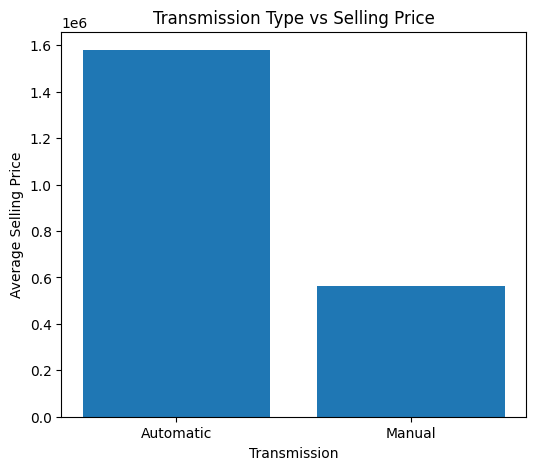

transmission_type
Automatic    1.579557e+06
Manual       5.652852e+05
Name: selling_price, dtype: float64


In [ ]:
#Do automatic cars have a higher resale value than manual cars?
transmission_price = (
    df.groupby("transmission_type")["selling_price"]
    .mean()
)

plt.figure(figsize=(6,5))
plt.bar(transmission_price.index, transmission_price.values)
plt.title("Transmission Type vs Selling Price")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")
plt.show()

print(transmission_price)

<Axes: xlabel='mileage', ylabel='Density'>

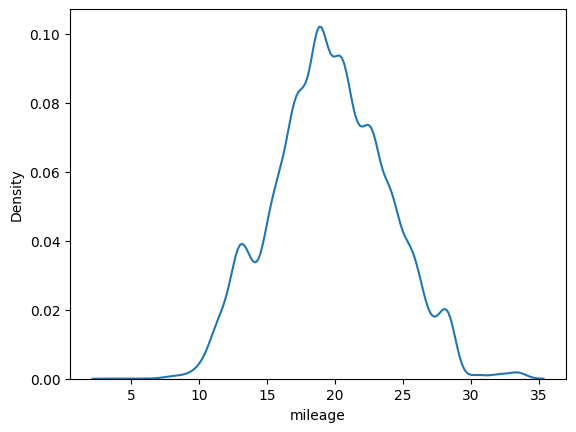

In [ ]:
sns.kdeplot(df['mileage'])



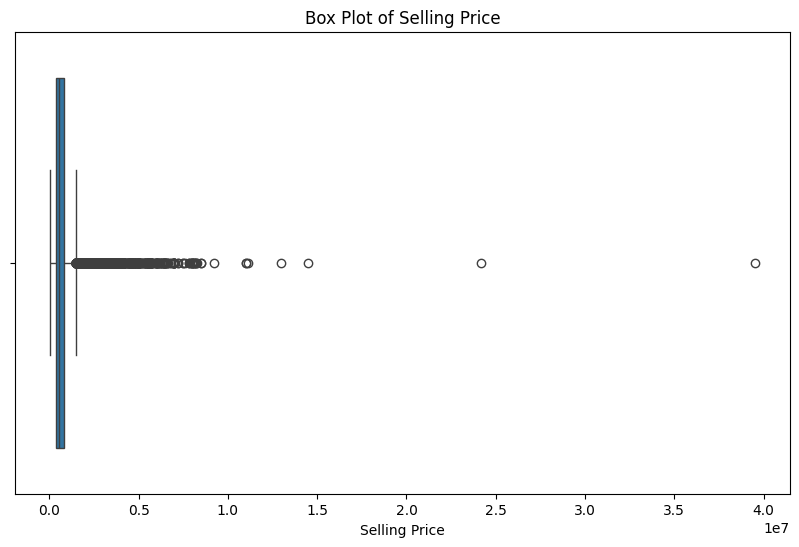

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['selling_price'])
plt.title('Box Plot of Selling Price')
plt.xlabel('Selling Price')
plt.show()

### Bivariate Analysis: Correlation Matrix and Scatter Plots

Bivariate analysis explores the relationship between two variables. Correlation helps quantify the strength and direction of linear relationships between numerical variables. Scatter plots provide a visual representation of these relationships.

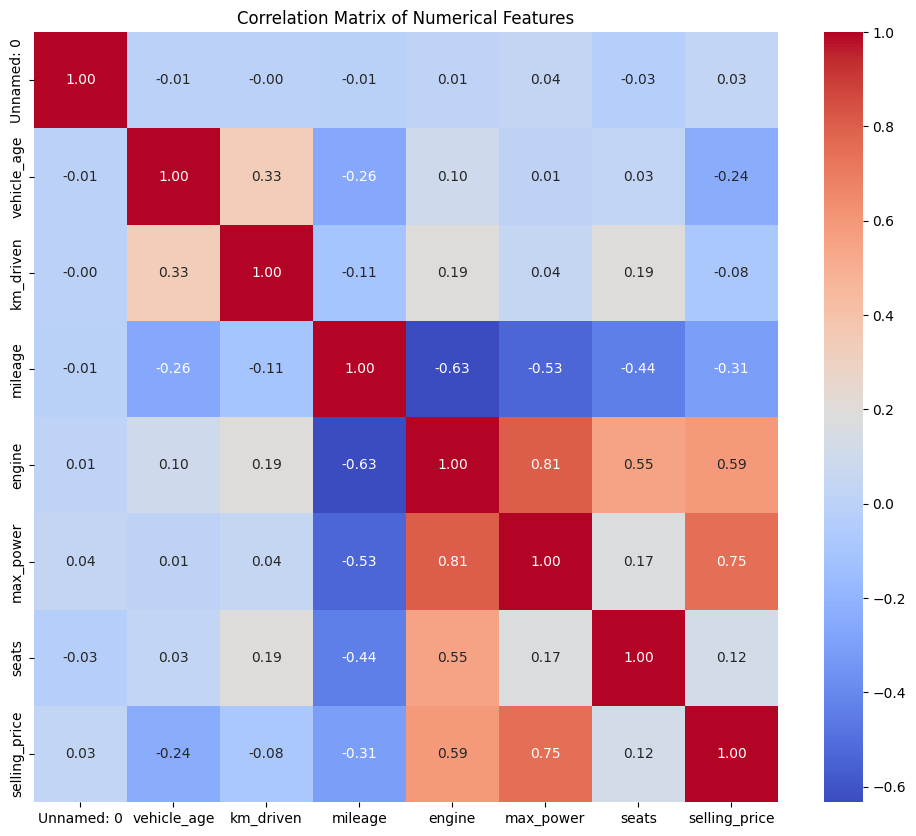

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#Bi-varince


Now, let's visualize the relationships between 'selling_price' and other numerical features using scatter plots.

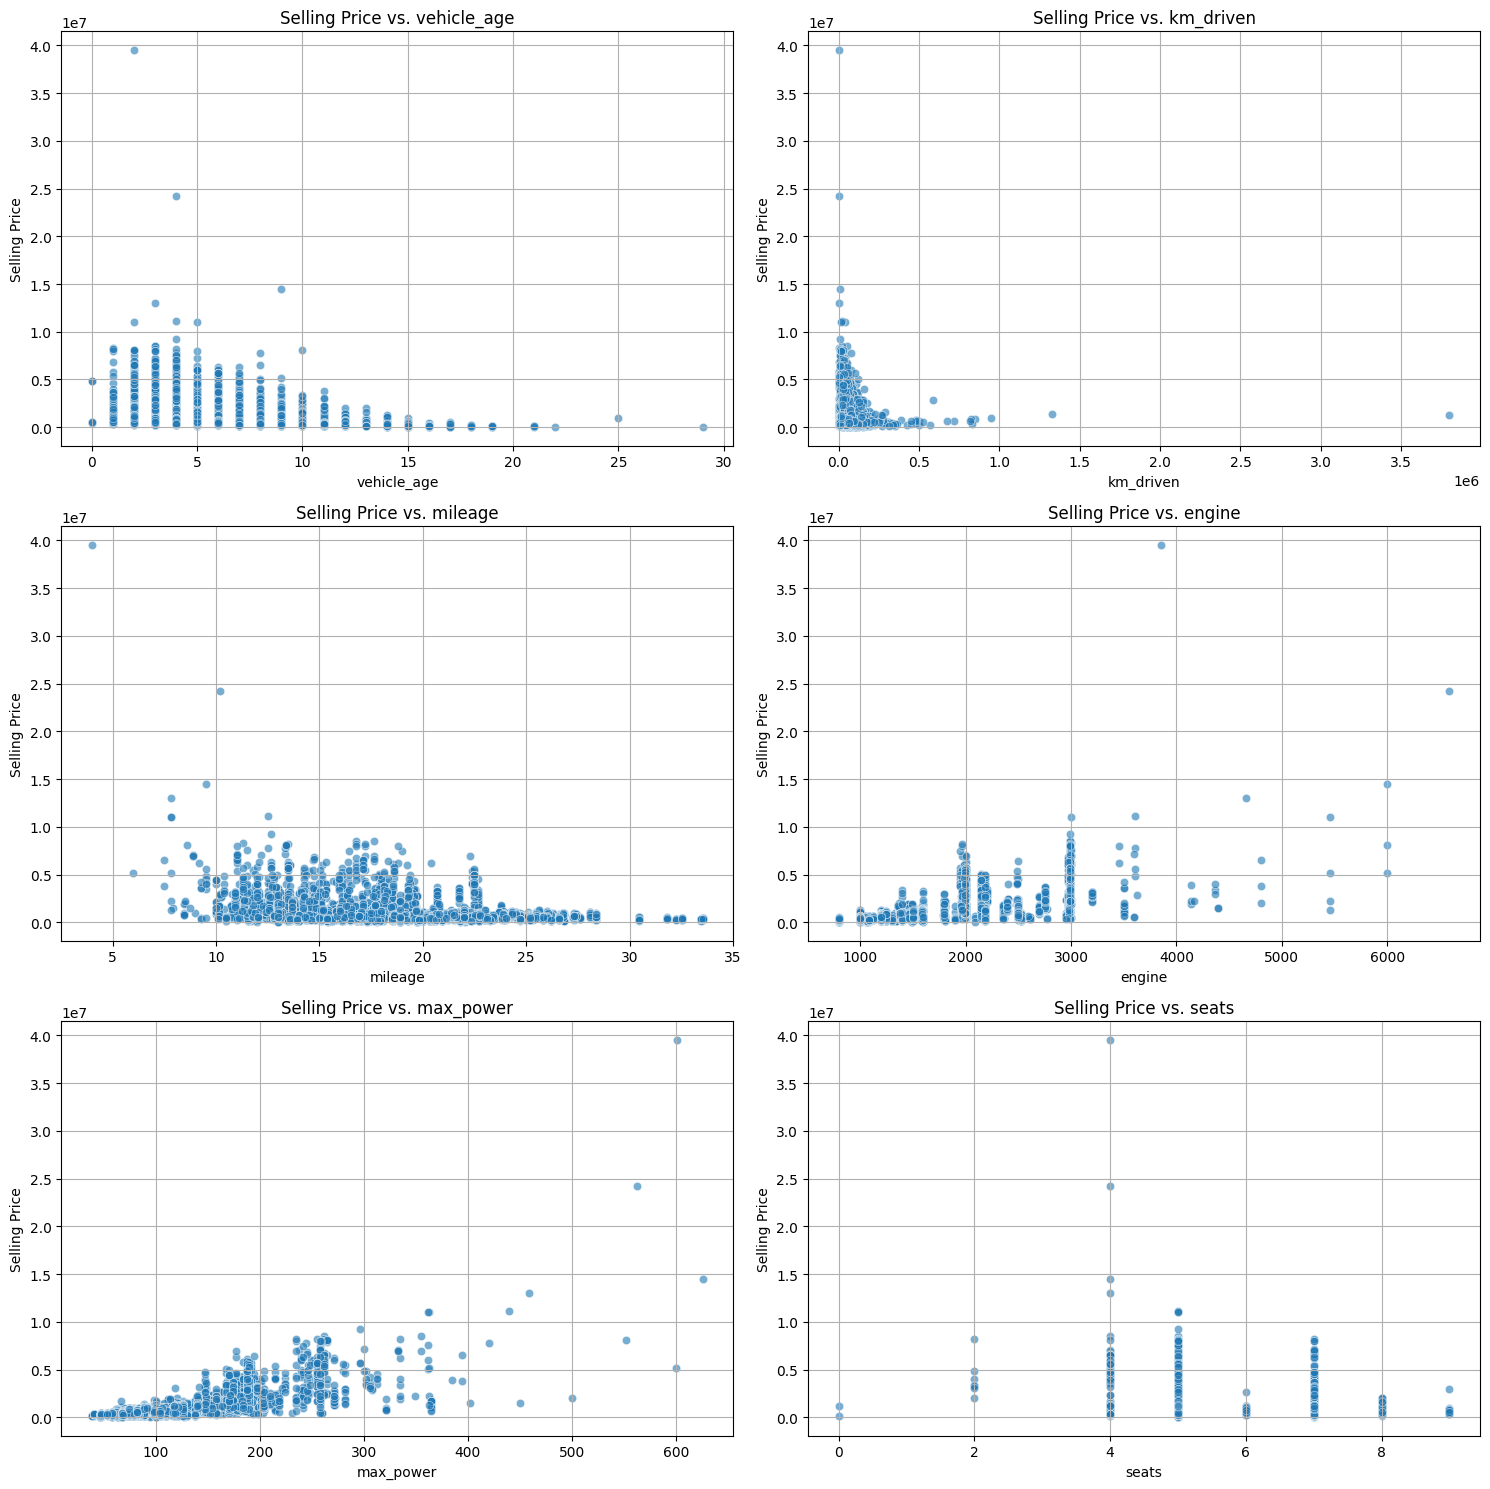

In [ ]:
numeric_features = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

# Calculate the number of rows needed for subplots (2 columns per row)
rows = (len(numeric_features) + 1) // 2

plt.figure(figsize=(15, 5 * rows))

for i, feature in enumerate(numeric_features):
    plt.subplot(rows, 2, i + 1)
    sns.scatterplot(x=df[feature], y=df['selling_price'], alpha=0.6)
    plt.title(f'Selling Price vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Selling Price')
    plt.grid(True)

plt.tight_layout()
plt.show()

Multivariable analysis

In [ ]:
df[numeric_features].corr()

,vehicle_age,km_driven,mileage,engine,max_power,seats
vehicle_age,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791
km_driven,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830
mileage,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280
engine,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236
max_power,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257
seats,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000


Hitmap

<Axes: >

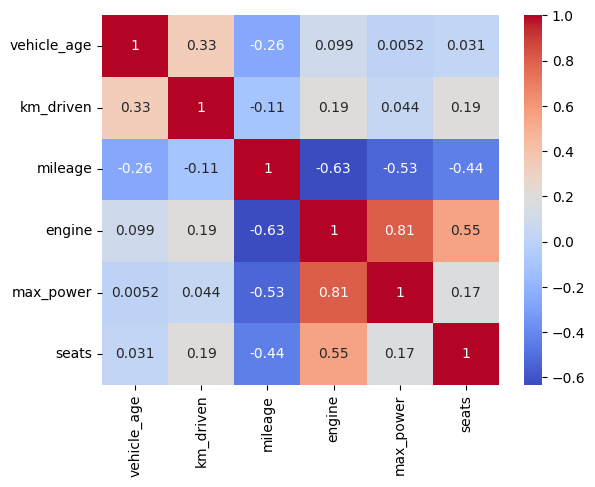

In [ ]:
sns.heatmap(df[numeric_features].corr(),annot=True,cmap='coolwarm')

Removing unnecessary

In [ ]:
data_model = df.copy()
data_model.drop(columns=['Unnamed: 0' , 'car_name' ,'brand','model'],inplace=True)
data_model

,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [ ]:
# Convetrting categorical column into numerical columns
# one hot encoding
data_model = pd.get_dummies(data_model)
data_model

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,True,False,False,False,False,False,True,False,True
1,5,20000,18.90,1197,82.00,5,550000,False,True,False,False,False,False,False,True,False,True
2,11,60000,17.00,1197,80.00,5,215000,False,True,False,False,False,False,False,True,False,True
3,9,37000,20.92,998,67.10,5,226000,False,True,False,False,False,False,False,True,False,True
4,6,30000,22.77,1498,98.59,5,570000,True,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,250000,True,False,False,False,False,False,False,True,False,True
15407,2,18000,17.50,1373,91.10,7,925000,True,False,False,False,False,False,False,True,False,True
15408,6,67000,21.14,1498,103.52,5,425000,True,False,False,False,True,False,False,False,False,True
15409,5,3800000,16.00,2179,140.00,7,1225000,True,False,False,False,True,False,False,False,False,True


In [ ]:
X = data_model.drop(columns=['selling_price'])
y = data_model['selling_price']
y

,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000
...,...
15406,250000
15407,925000
15408,425000
15409,1225000


In [ ]:
#2 Tain-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
lr = LinearRegression()

# Combine X_train and y_train to drop NaN rows synchronously
train_df = pd.concat([X_train, y_train], axis=1)
train_df.dropna(inplace=True)
X_train_cleaned = train_df.drop(columns=['selling_price'])
y_train_cleaned = train_df['selling_price']

# Combine X_test and y_test to drop NaN rows synchronously
test_df = pd.concat([X_test, y_test], axis=1)
test_df.dropna(inplace=True)
X_test_cleaned = test_df.drop(columns=['selling_price'])
y_test_cleaned = test_df['selling_price']

lr.fit(X_train_cleaned,y_train_cleaned)
y_pred = lr.predict(X_test_cleaned)



In [ ]:
# Evaluation using cleaned test sets
print("R2 Score:", r2_score(y_test_cleaned, y_pred))
print("MAE:", mean_absolute_error(y_test_cleaned, y_pred))
print("MSE:", mean_squared_error(y_test_cleaned, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_cleaned, y_pred)))


R2 Score: 0.665109416466749
MAE: 278351.6282614246
MSE: 252099533088.12735
RMSE: 502095.143462001


In [ ]:
coefficients = pd.DataFrame({'Features ' : X_train.columns , 'coefficients' : lr.coef_})
coefficients


,Features,coefficients
0,vehicle_age,-61418.642664
1,km_driven,-1.167280
2,mileage,16265.425270
3,engine,117.823783
4,max_power,14940.315784
5,seats,11365.160209
6,seller_type_Dealer,27130.112704
7,seller_type_Individual,28804.127310
8,seller_type_Trustmark Dealer,-55934.240015
9,fuel_type_CNG,6682.500263


In [ ]:
!git clone https://github.com/khushiYadav-01/Car-Price-Predictor.git

Cloning into 'Car-Price-Predictor'...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content

drive  sample_data


In [5]:
!ls

drive  sample_data


In [9]:
!git --version

git version 2.34.1


In [11]:
!git ls-remote https://github.com/khushiYadav-01/Car-Price-Predictor.git

In [12]:
!find /content/drive -name "CarDekho.ipynb"

/content/drive/MyDrive/Colab Notebooks/CarDekho.ipynb


In [13]:
%cd /content

/content


In [14]:
!git clone https://github.com/khushiYadav-01/Car-Price-Predictor.gitS

Cloning into 'Car-Price-Predictor'...


In [15]:
!find /content -maxdepth 1 -type d

/content
/content/.config
/content/Car-Price-Predictor
/content/drive
/content/sample_data
